In [56]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [57]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [58]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [59]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

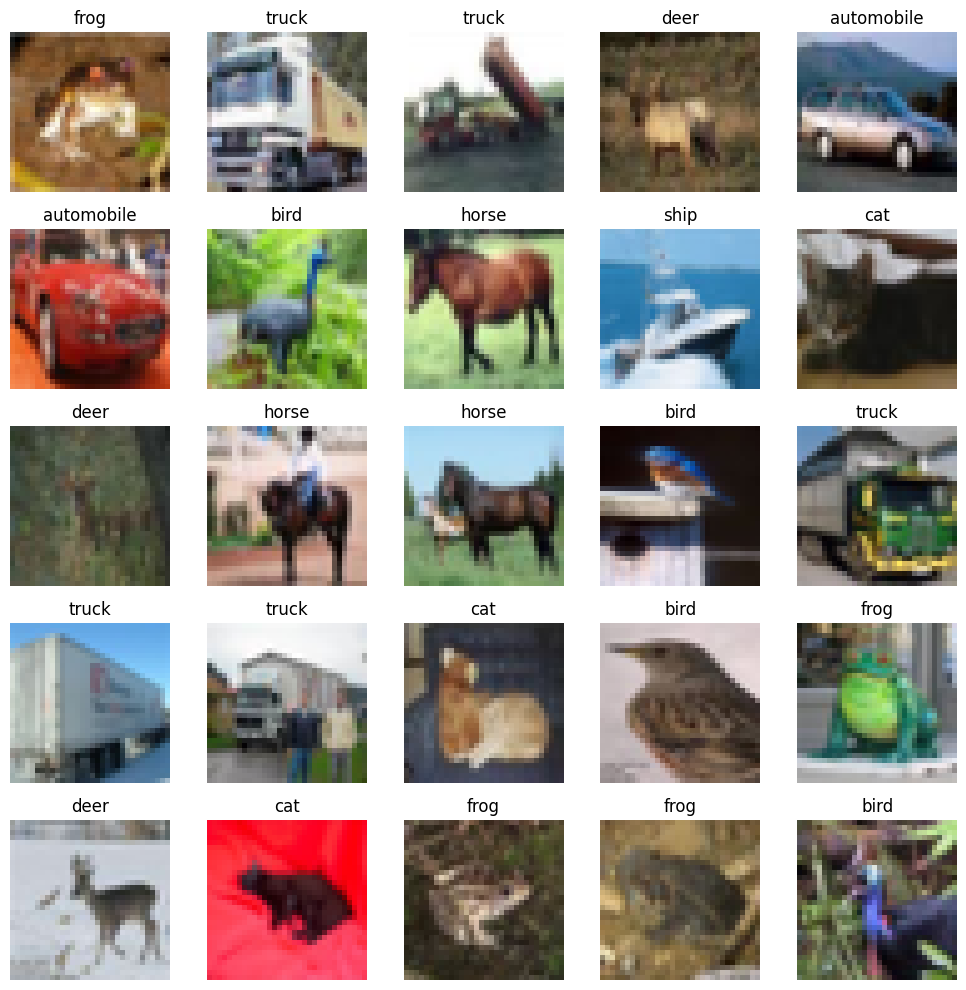

In [60]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(class_names[label], count)

airplane 5000
automobile 5000
bird 5000
cat 5000
deer 5000
dog 5000
frog 5000
horse 5000
ship 5000
truck 5000


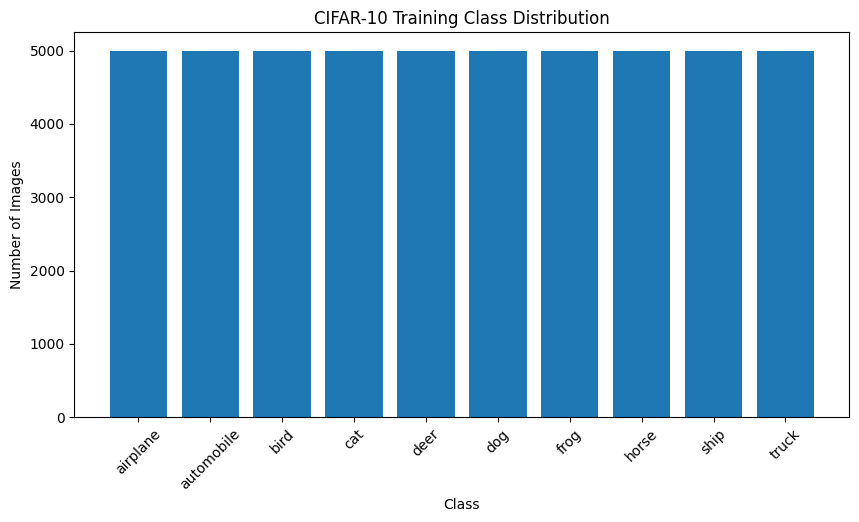

In [62]:
plt.figure(figsize=(10, 5))

plt.bar(class_names, counts)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [63]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(class_names[label], count)

airplane 5000
automobile 5000
bird 5000
cat 5000
deer 5000
dog 5000
frog 5000
horse 5000
ship 5000
truck 5000


In [64]:
print(X_train.min())
print(X_train.max())

0
255


In [65]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [66]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [67]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [68]:
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [69]:
model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
Dense(10, activation="softmax")

<Dense name=dense_8, built=False>

In [72]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [73]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 141ms/step - accuracy: 0.3851 - loss: 1.6731 - val_accuracy: 0.5073 - val_loss: 1.3665
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 141ms/step - accuracy: 0.5444 - loss: 1.2817 - val_accuracy: 0.6045 - val_loss: 1.1507
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 137ms/step - accuracy: 0.6118 - loss: 1.1037 - val_accuracy: 0.6603 - val_loss: 0.9958
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 145ms/step - accuracy: 0.6520 - loss: 0.9918 - val_accuracy: 0.6928 - val_loss: 0.8708
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.6843 - loss: 0.9045 - val_accuracy: 0.7090 - val_loss: 0.8440
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 148ms/step - accuracy: 0.7090 - loss: 0.8375 - val_accuracy: 0.7230 - val_loss: 0.7994
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 137ms/step - accuracy: 0.7274 - loss: 0.7825 - val_accuracy: 0.7313 - val_loss: 0.7840
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.7430 - los

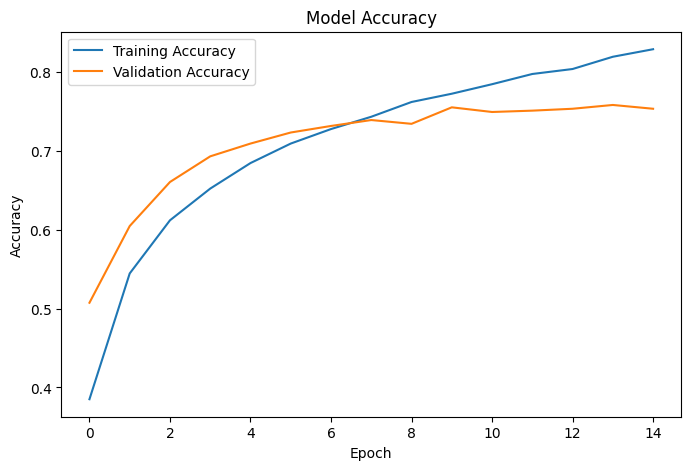

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

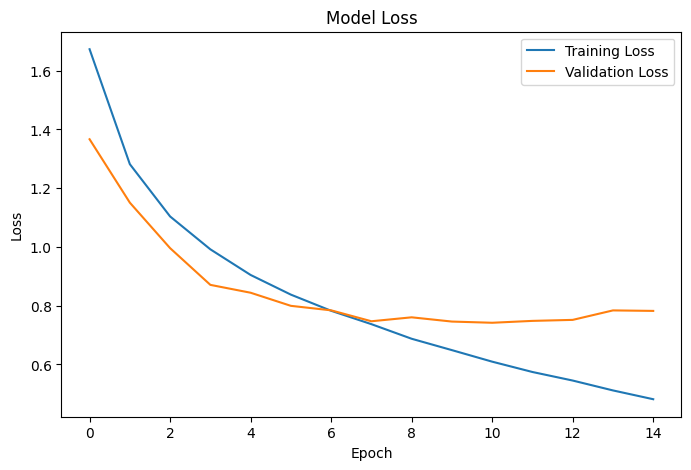

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [76]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7436 - loss: 0.8155
Test Loss: 0.8154919147491455
Test Accuracy: 0.7436000108718872


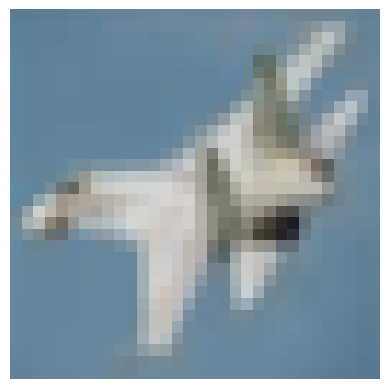

In [77]:
image = X_test[10]

plt.imshow(image)
plt.axis("off")
plt.show()

In [78]:
prediction = model.predict(
    np.expand_dims(image, axis=0)
)

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


array([[7.4883677e-02, 5.9853312e-07, 1.3492940e-02, 7.5565162e-03,
        8.6457241e-01, 3.3444541e-03, 8.4043922e-06, 3.5632886e-02,
        4.9708335e-04, 1.1034161e-05]], dtype=float32)

In [79]:
predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[10]])

Predicted: deer
Actual: airplane


In [80]:
confidence = np.max(prediction) * 100

print("Prediction:", class_names[predicted_class])
print(f"Confidence: {confidence:.2f}%")
print("Actual:", class_names[y_test[10]])

Prediction: deer
Confidence: 86.46%
Actual: airplane


Evalaution with Confused Matrix

In [81]:
from sklearn.metrics import confusion_matrix, classification_report

In [82]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [83]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[787   4  52  13  23   9   6  18  66  22]
 [ 26 777   9  10  11   3  10   5  37 112]
 [ 59   1 639  46 104  63  41  35  10   2]
 [ 16   5  65 540  91 188  34  40  14   7]
 [ 15   0  60  39 759  32  20  68   7   0]
 [ 10   3  46 147  55 669  11  51   3   5]
 [  4   0  62  68  61  37 749   7   6   6]
 [  8   0  37  21  68  42   3 816   3   2]
 [ 52  14  13  17  10   2   3   5 864  20]
 [ 27  35   8  15   5   7   4  32  31 836]]


In [84]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.78      0.79      0.79      1000
  automobile       0.93      0.78      0.85      1000
        bird       0.64      0.64      0.64      1000
         cat       0.59      0.54      0.56      1000
        deer       0.64      0.76      0.69      1000
         dog       0.64      0.67      0.65      1000
        frog       0.85      0.75      0.80      1000
       horse       0.76      0.82      0.79      1000
        ship       0.83      0.86      0.85      1000
       truck       0.83      0.84      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [85]:
model.save("cifar10_model.keras")

In [86]:
from tensorflow.keras.models import load_model

model = load_model("cifar10_model.keras")